## **SETUP**

In [44]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from catboost import CatBoostClassifier
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

## **EDA**

In [45]:
df = pd.read_csv("playground-series-s6e6/train.csv")

baris, kolom = df.shape
print(f"Baris: {baris}, Kolom: {kolom}")
df.head()

Baris: 577347, Kolom: 12


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [46]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [47]:
X = df.drop(["id", "class"], axis=1)
y = df["class"]

cat_col = ["spectral_type", "galaxy_population"]
for col in cat_col:
    print(f"{col}: | ", end="")
    for i in X[col].unique():
        print(i, end=" | ")
    print()

spectral_type: | M | O/B | G/K | A/F | 
galaxy_population: | Red_Sequence | Blue_Cloud | 


In [48]:
dup = df.duplicated().sum()

print(f"IsDUplicate? {"No" if dup == 0 else "Yes"}")

IsDUplicate? No


### **Cek Outlier**

In [49]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
alpha,577347.0,181.616673,96.242941,0.011684,132.161499,188.681465,231.829693,359.999810
delta,577347.0,21.834654,18.933570,-17.966988,2.474097,21.484412,36.988310,79.158322
u,577347.0,22.441926,2.018135,-0.139225,20.977090,22.570222,23.869103,28.253263
g,577347.0,21.007273,1.795426,13.535483,19.865005,21.467820,22.292715,27.620208
r,577347.0,19.962811,1.648964,12.579407,18.820671,20.431153,21.164096,25.254499
i,577347.0,19.378911,1.580059,11.962781,18.306820,19.631642,20.608191,27.910853
z,577347.0,19.041136,1.584365,11.682803,17.973192,19.188598,20.162111,26.826867
redshift,577347.0,0.723135,0.810070,-0.009970,0.181052,0.497525,0.881390,7.010780


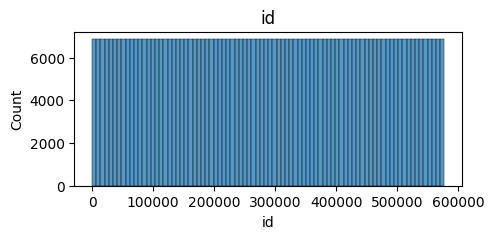

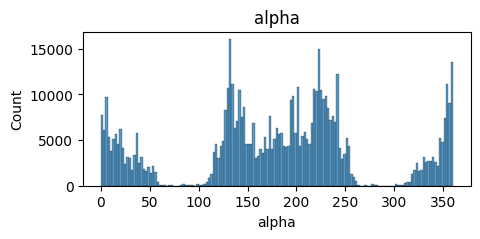

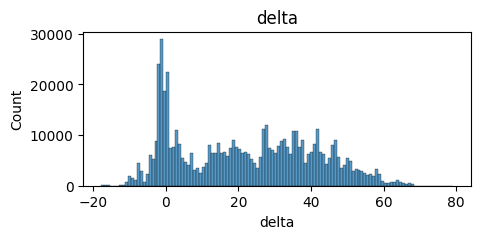

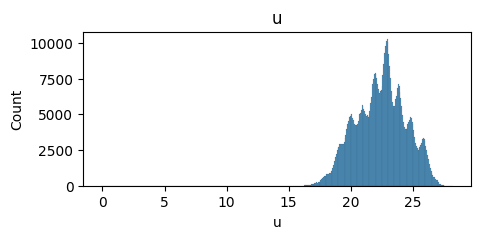

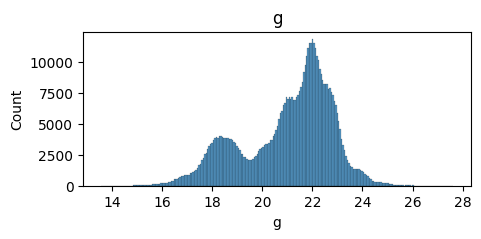

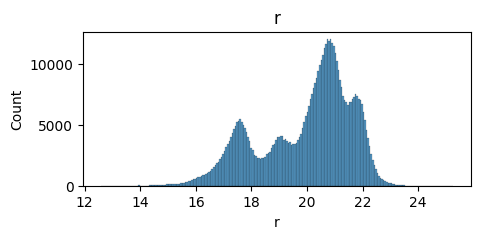

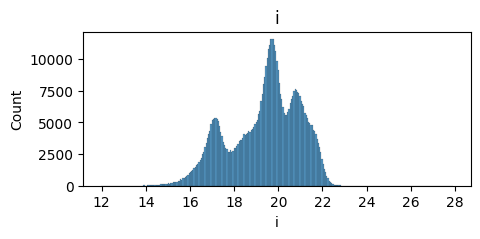

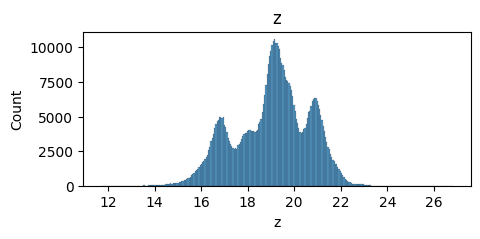

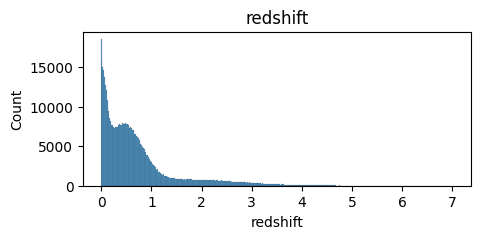

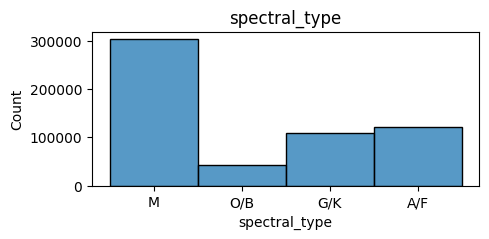

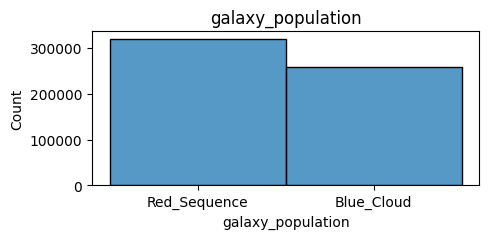

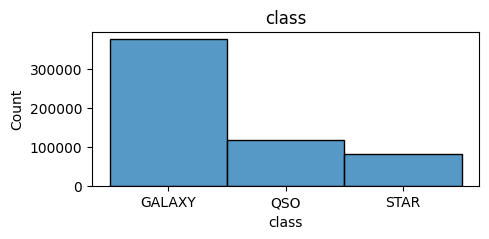

alpha 0
delta 0
u 315
g 2806
r 1677
i 1277
z 1476
redshift 20965


In [62]:
for col in df.columns:
    plt.figure(figsize=(5,2))
    sns.histplot(x=df[col])
    plt.title(col)
    plt.show()

def detect_outlier_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = df[(df[col] < lower) | (df[col] > upper)]

    return outlier


for col in X.select_dtypes(include='number').columns:
    out = detect_outlier_iqr(X, col)
    print(col, len(out))

Temuan:
- redshift sangat skew (skew kanan) - banyak data berkumpul di kiri. berarti kebanyakan bintang berada tidak terlalu jauh dari pengamat (redshift kecil = jarak dekat)
- g, r hati-hati

Mitigasi:
- log dan cek hubungan redshift dan class. apakah linear?
Jika sesuai teori, seharusnya redshift besar = QSO, redshift kecil = bintang
--> QSO > Galaxy > Star

### **Apakah Redshift (Jarak) berhubungan dengan Class?**

In [ ]:
X_log = X.copy()

X_log['redshift'] = np.log1p(df['redshift'])

<Figure size 800x500 with 0 Axes>

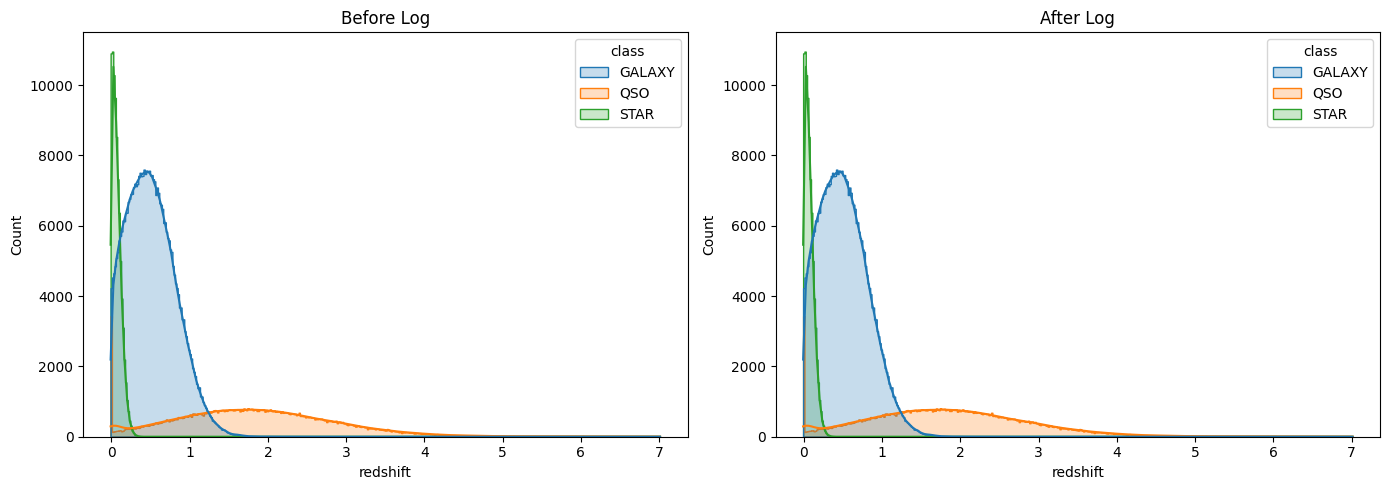

In [ ]:
plt.figure(figsize=(8,5))

fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(
    data=df,
    x="redshift",
    hue="class",
    kde=True,
    element="step",
    ax = ax[0]
)
ax[0].set_title("Before Log")

sns.histplot(
    data=X_log,
    x="redshift",
    hue="class",
    kde=True,
    element="step",
    ax = ax[1]
)
ax[1].set_title("After Log")

plt.tight_layout()
plt.show()

yap.. kurang lebih cukup sesuai.. yang mendominasi redshift kecil = star, redshift sedang = galaxy, redshift besar = QSO

redshift berhubungan dengan class

### **Apakah galaxy population (suhu) berhubungan dengan redshift (kecerlangan)?**

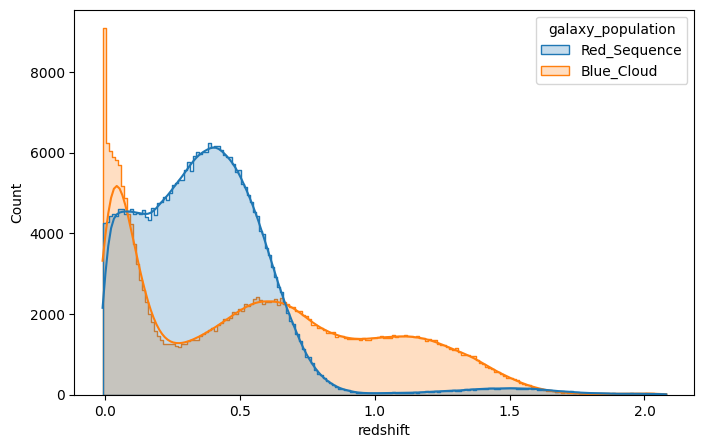

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=X,
    x="redshift",
    hue="galaxy_population",
    kde=True,
    element="step"
)

plt.show()

dari histogram, kita tahu bahwa sepertinya tidak ada hubungan antara redshift dengan galaxy population

- redshiftt --> terang / gelap

- galaxy_population --> suhu

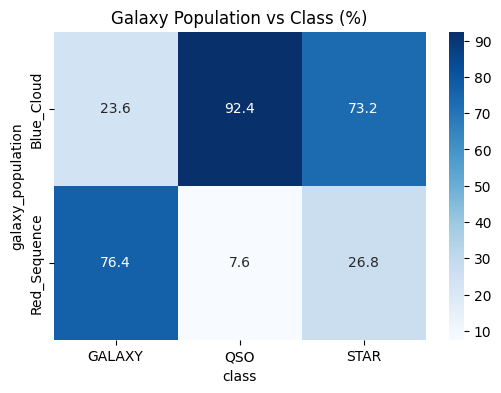

In [66]:
ct = pd.crosstab(X['galaxy_population'], y, normalize = "columns")* 100
# ct = pd.crosstab(X['galaxy_population'], y)

plt.figure(figsize=(6,4))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues")

plt.title("Galaxy Population vs Class (%)")
plt.show()

## **Clustering**

In [ ]:
def  Clustering(df, col, n, name, is_scaling=True):
    X_cluster = df[col]
    
    if not is_scaling:
        X_scaled = StandardScaler().fit_transform(X_cluster)
    else:
        X_scaled = X_cluster

    kmeans = KMeans(n_clusters= n, random_state=42)
    cluster = kmeans.fit_predict(X_scaled)
    X_cluster = pd.DataFrame(cluster, columns=[name])
    X_cluster = X_cluster.astype("category")
    
    return X_cluster

### **Alpha Delta (Location)**

## **Mutual Information**

In [ ]:
# Label encoding for categoricals
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()
diskrit = X.dtypes == int

In [ ]:
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, diskrit)
mi_scores

redshift             0.514988
g-r                  0.321156
spectral_type        0.299984
r-i                  0.218326
z                    0.211511
galaxy_population    0.192690
u                    0.178882
g                    0.174583
u-g                  0.171346
i                    0.158246
alpha                0.139253
delta                0.130698
r                    0.097938
i-z                  0.074758
Name: MI Scores, dtype: float64

In [ ]:
model = CatBoostClassifier(
    iterations=1000, 
    learning_rate= 0.05,
    depth = 8,
    loss_function= 'MultiClass',
    eval_metric= 'TotalF1',
    cat_features= cat_col,
    random_seed= 42)

## **Feature Engineering**

In [ ]:
#seberapa  dekat ke infrared
df["u-g"] = df["u"] - df["g"]
df["g-r"] = df["g"] - df["r"]
df["r-i"] = df["r"] - df["i"]
df["i-z"] = df["i"] - df["z"]

fe = ["u-g", 'g-r','r-i', 'i-z']

### **MI Score after Feature Engineering**

In [ ]:
y = df["class"]
X = df.drop(["class", "alpha", "delta"], axis=1)

# Label encoding for categoricals
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()
diskrit = X.dtypes == int

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, diskrit)
mi_scores

id                   0.879847
redshift             0.514987
g-r                  0.321156
spectral_type        0.299984
r-i                  0.218325
z                    0.211507
galaxy_population    0.192690
u                    0.178884
g                    0.174585
u-g                  0.171346
i                    0.158241
r                    0.097941
i-z                  0.074759
Name: MI Scores, dtype: float64

### **Alpha Delta (Location)**

In [ ]:
a_d = ['alpha', 'delta']

cluster_loc = Clustering(X, a_d, 3, 'location', is_scaling= False)

cluster_loc.head()

,location
0,0
1,1
2,1
3,1
4,0


In [ ]:
X_cluster = X.join(cluster_loc)

X_cluster.head()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,u-g,g-r,r-i,i-z,location
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0,0,3.576564,1.537632,1.100813,0.636056,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0,0,1.691447,1.499854,0.361141,0.439634,1
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,1,1,-0.043925,-0.092712,0.589211,0.025263,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,0,0,2.254320,2.032982,0.652096,0.450706,1
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,0,0,2.231478,1.237231,0.335002,0.283262,0


cari hubungan location dengan class

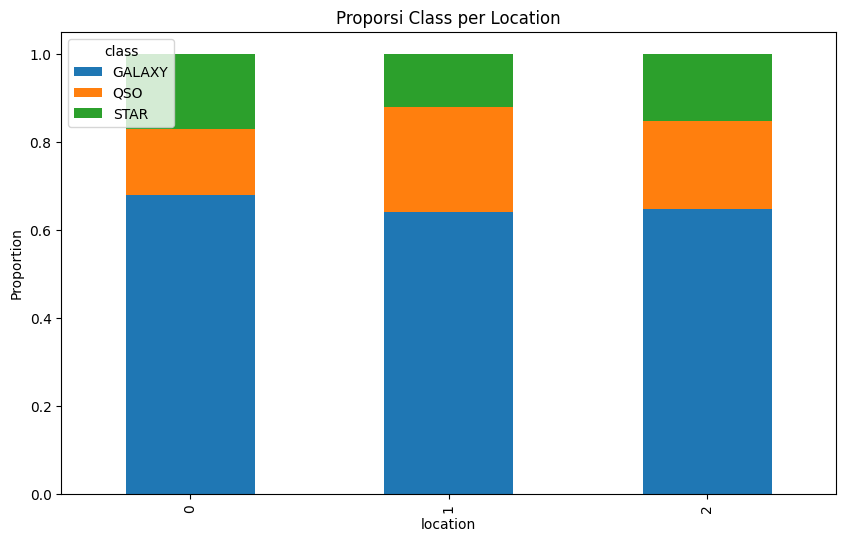

In [ ]:
ct = pd.crosstab(X_cluster['location'], y, normalize= 'index')

ct.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Proporsi Class per Location')
plt.ylabel('Proportion')
plt.show()

class menyebar merata di seluruh cluster. tidak ada yang mendominasi. jadi, a_d location bisa di drop. 

In [ ]:
X = X_cluster.drop(['location', 'alpha', 'delta'], axis=1)
X.head()

KeyError: "['location', 'alpha', 'delta'] not found in axis"

### **PCA**

In [ ]:
def pca_gen(df, col, is_scaling= True):
    pca = PCA()
    pca_col = df[col]

    if is_scaling:
        X_scaled = StandardScaler().fit_transform(pca_col)
    else:
        X_scaled = pca_col

    X_pca = pca.fit_transform(X_scaled)

    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)

    loadings = pd.DataFrame(
    pca.components_.T,  # transpose the matrix of loadings
    columns=component_names,  # so the columns are the principal components
    index=pca_col.columns,  # and the rows are the original features
)
    return X_pca, loadings, plot_variance(pca)

def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel="Component", title="% Explained Variance", ylim=(0.0, 1.0)
    )
    # Cumulative Variance
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel="Component", title="% Cumulative Variance", ylim=(0.0, 1.0)
    )
    # Set up figure
    fig.set(figwidth=8, dpi=100)
    return axs

,PC1,PC2,PC3,PC4
u-g,0.411861,-0.557286,0.689703,-0.210030
g-r,0.631002,0.040705,-0.110409,0.766805
r-i,0.527112,-0.211075,-0.642153,-0.515015
i-z,0.392887,0.802012,0.315848,-0.320402


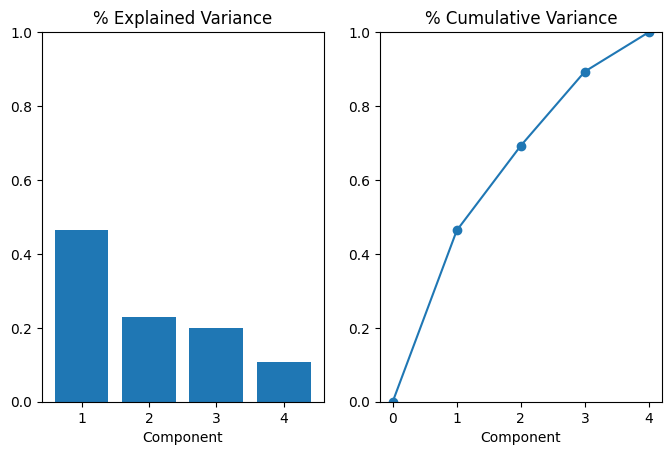

In [ ]:
X_pca, loadings, variance_plot = pca_gen(df, filter_col)

loadings

AttributeError: 'PCA' object has no attribute 'n_components_'

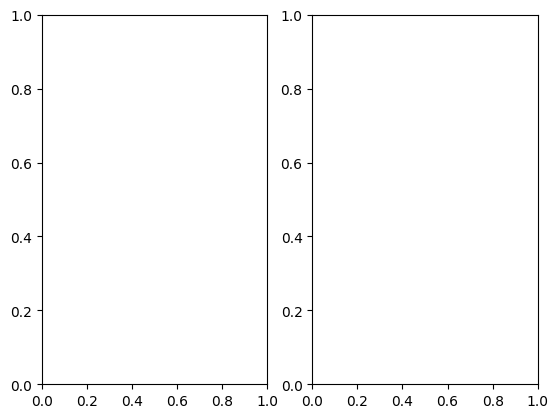

In [ ]:
pca= PCA()
plot_variance(pca)